# Enhanced PyTorch Codebase Knowledge Graph

This notebook demonstrates how to visualize and explore the enhanced PyTorch codebase knowledge graph with edge relationships.

## What's New

This enhanced version includes:
- Edge relationships between components
- Visualization of neighbors of torch.nn.Linear
- Detailed analysis of Linear's inheritance relationships
- Comprehensive exploration of PyTorch subsystems

PYTORCH CODEBASE KNOWLEDGE GRAPH

Graph Statistics:
  Nodes: 206
  Edges: 115

Node Types:
  module: 90
  other: 78
  class: 25
  function: 13

Edge Types:
  imports: 57
  calls: 35
  inherits: 23

Connected Components Analysis:
  Largest component: 40 nodes
  Total components: 116
Showing top components: 100 nodes


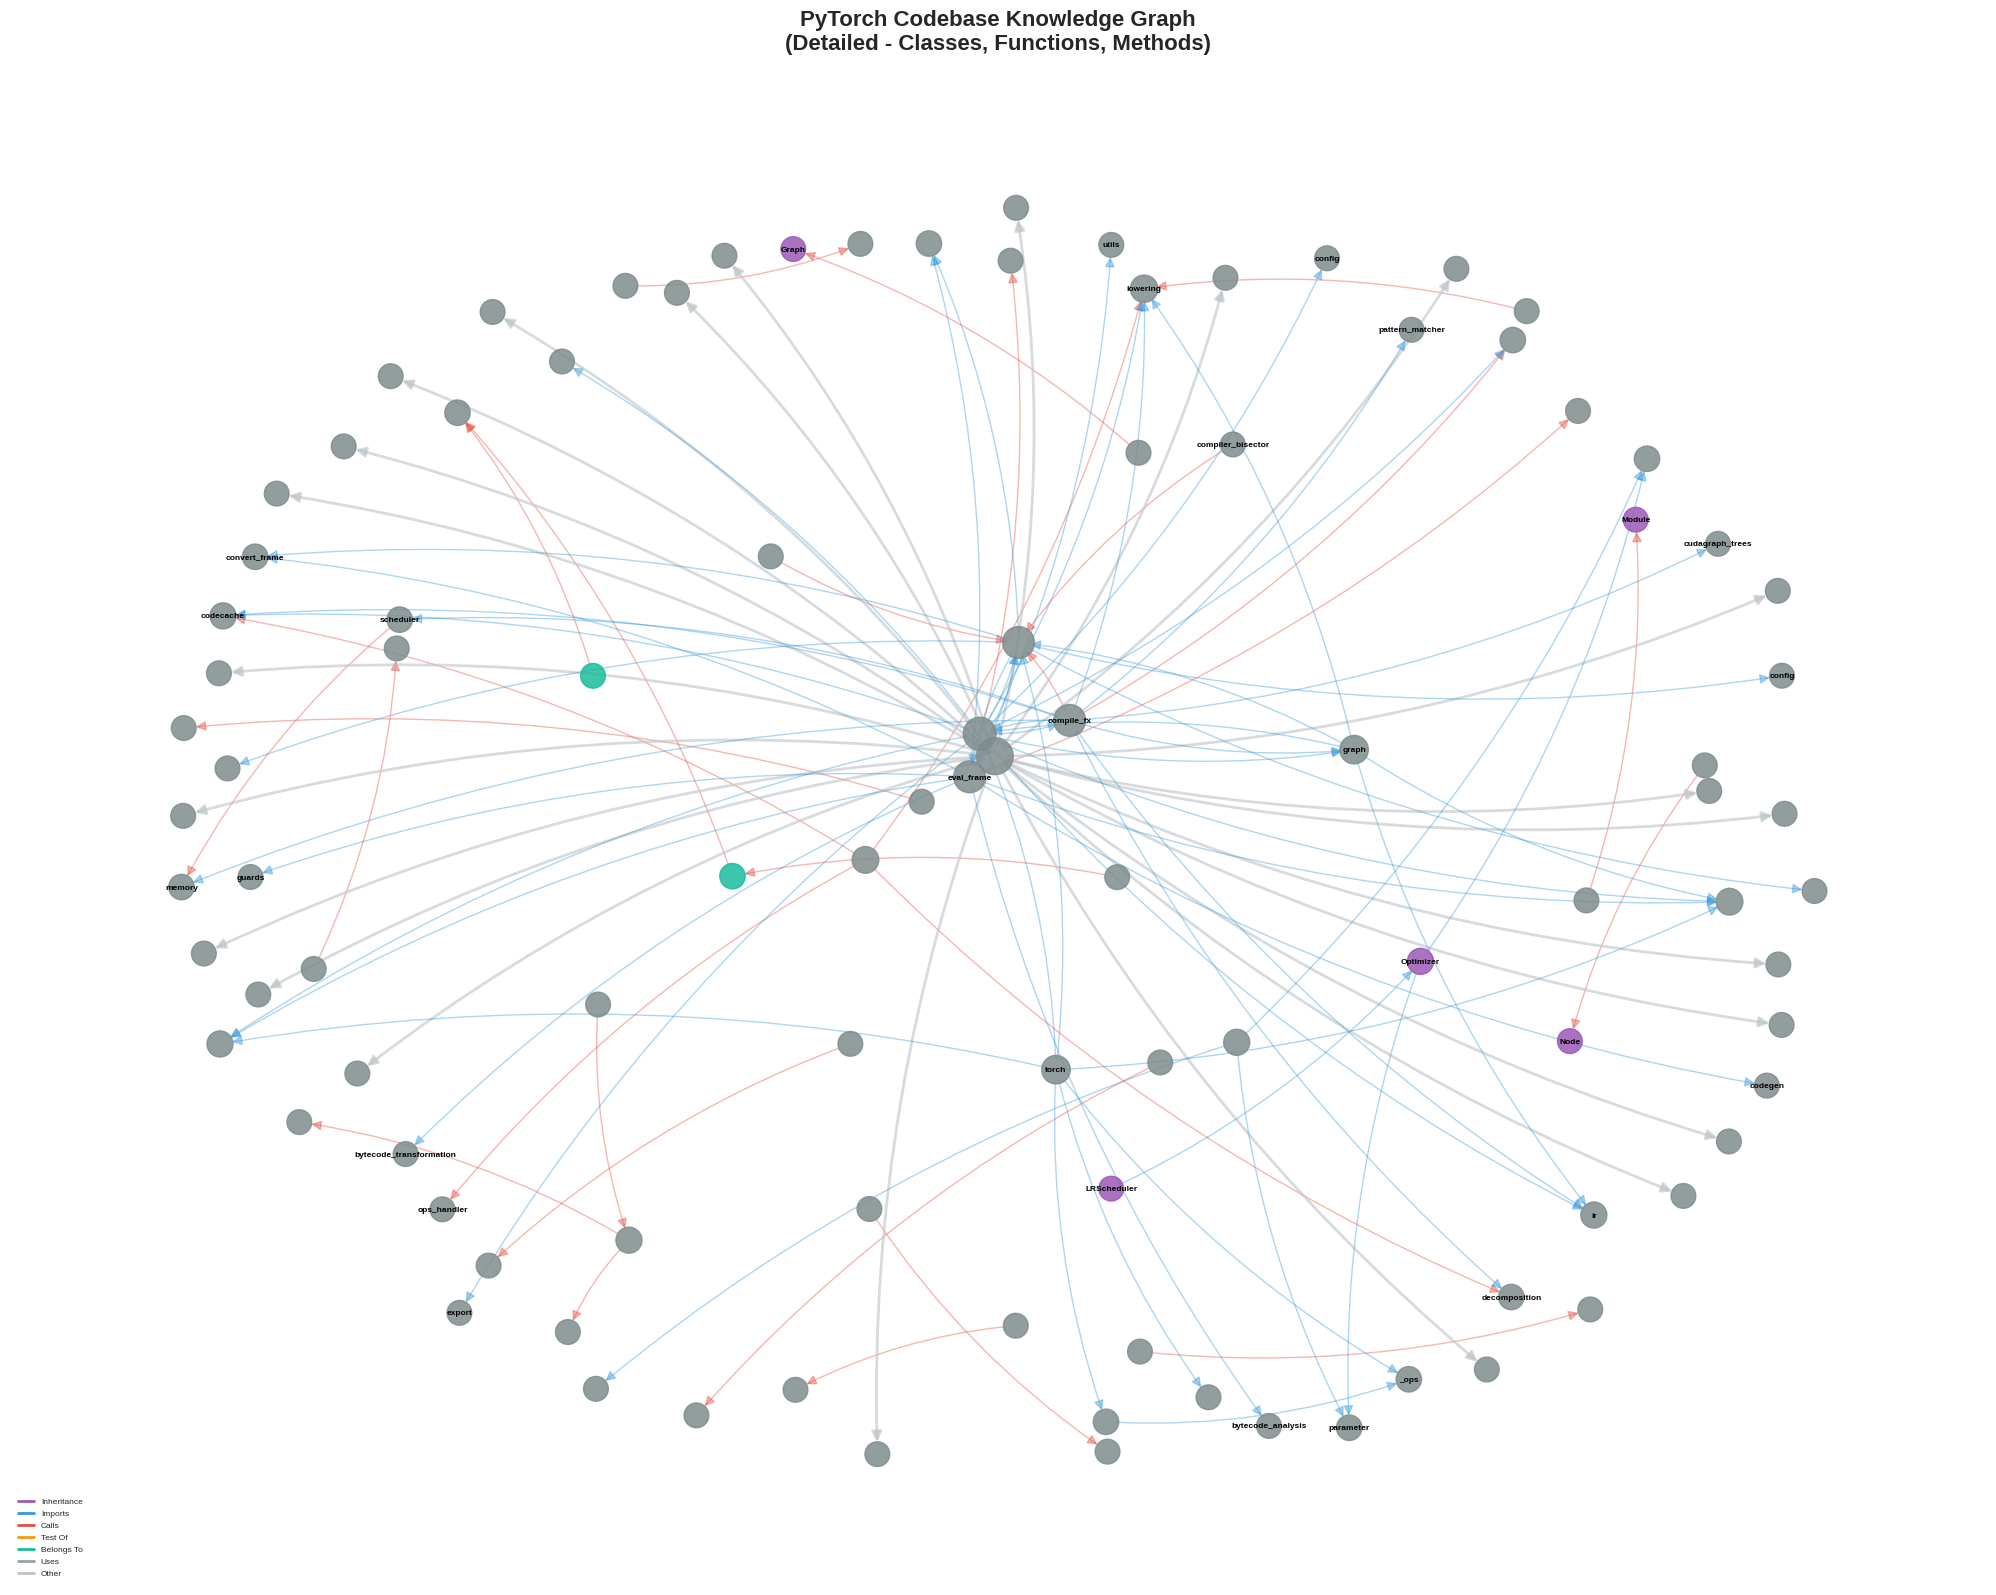


INTERACTIVE GRAPH EXPLORATION

1. Most Connected Nodes (Top 15):
   Node ID (Name) - Connections
   torch.nn.modules.module.Module - 23
   torch._inductor                - 15
   eval_frame                     - 13
   compile_fx                     - 13
   torch._dynamo                  - 13
   graph                          - 7
   torch                          - 7
   lowering                       - 5
   torch._inductor.graph.lower    - 4
   torch.fx                       - 4
   ir                             - 3
   torch.nn.Module.__call__       - 3
   Optimizer                      - 3
   codecache                      - 3
   torch.autograd                 - 3

2. Classes by Module:

   fx:
     - Node
     - Graph

   modules:
     - Module

   optim:
     - Optimizer
     - LRScheduler

3. Key Subsystems:

   TorchInductor (0 components):

   TorchDynamo (0 components):

   TorchFX (1 components):
     - compile_fx

   torch.nn Classes (1):
     - Module

4. Key Inheritance Chain

In [1]:
# Run the enhanced visualization script
%run visualize_knowledge_graph.py

PYTORCH CODEBASE KNOWLEDGE GRAPH

Graph Statistics:
  Nodes: 206
  Edges: 115

Node Types:
  module: 90
  other: 78
  class: 25
  function: 13

Edge Types:
  imports: 57
  calls: 35
  inherits: 23

Connected Components Analysis:
  Largest component: 40 nodes
  Total components: 116
Showing top components: 100 nodes


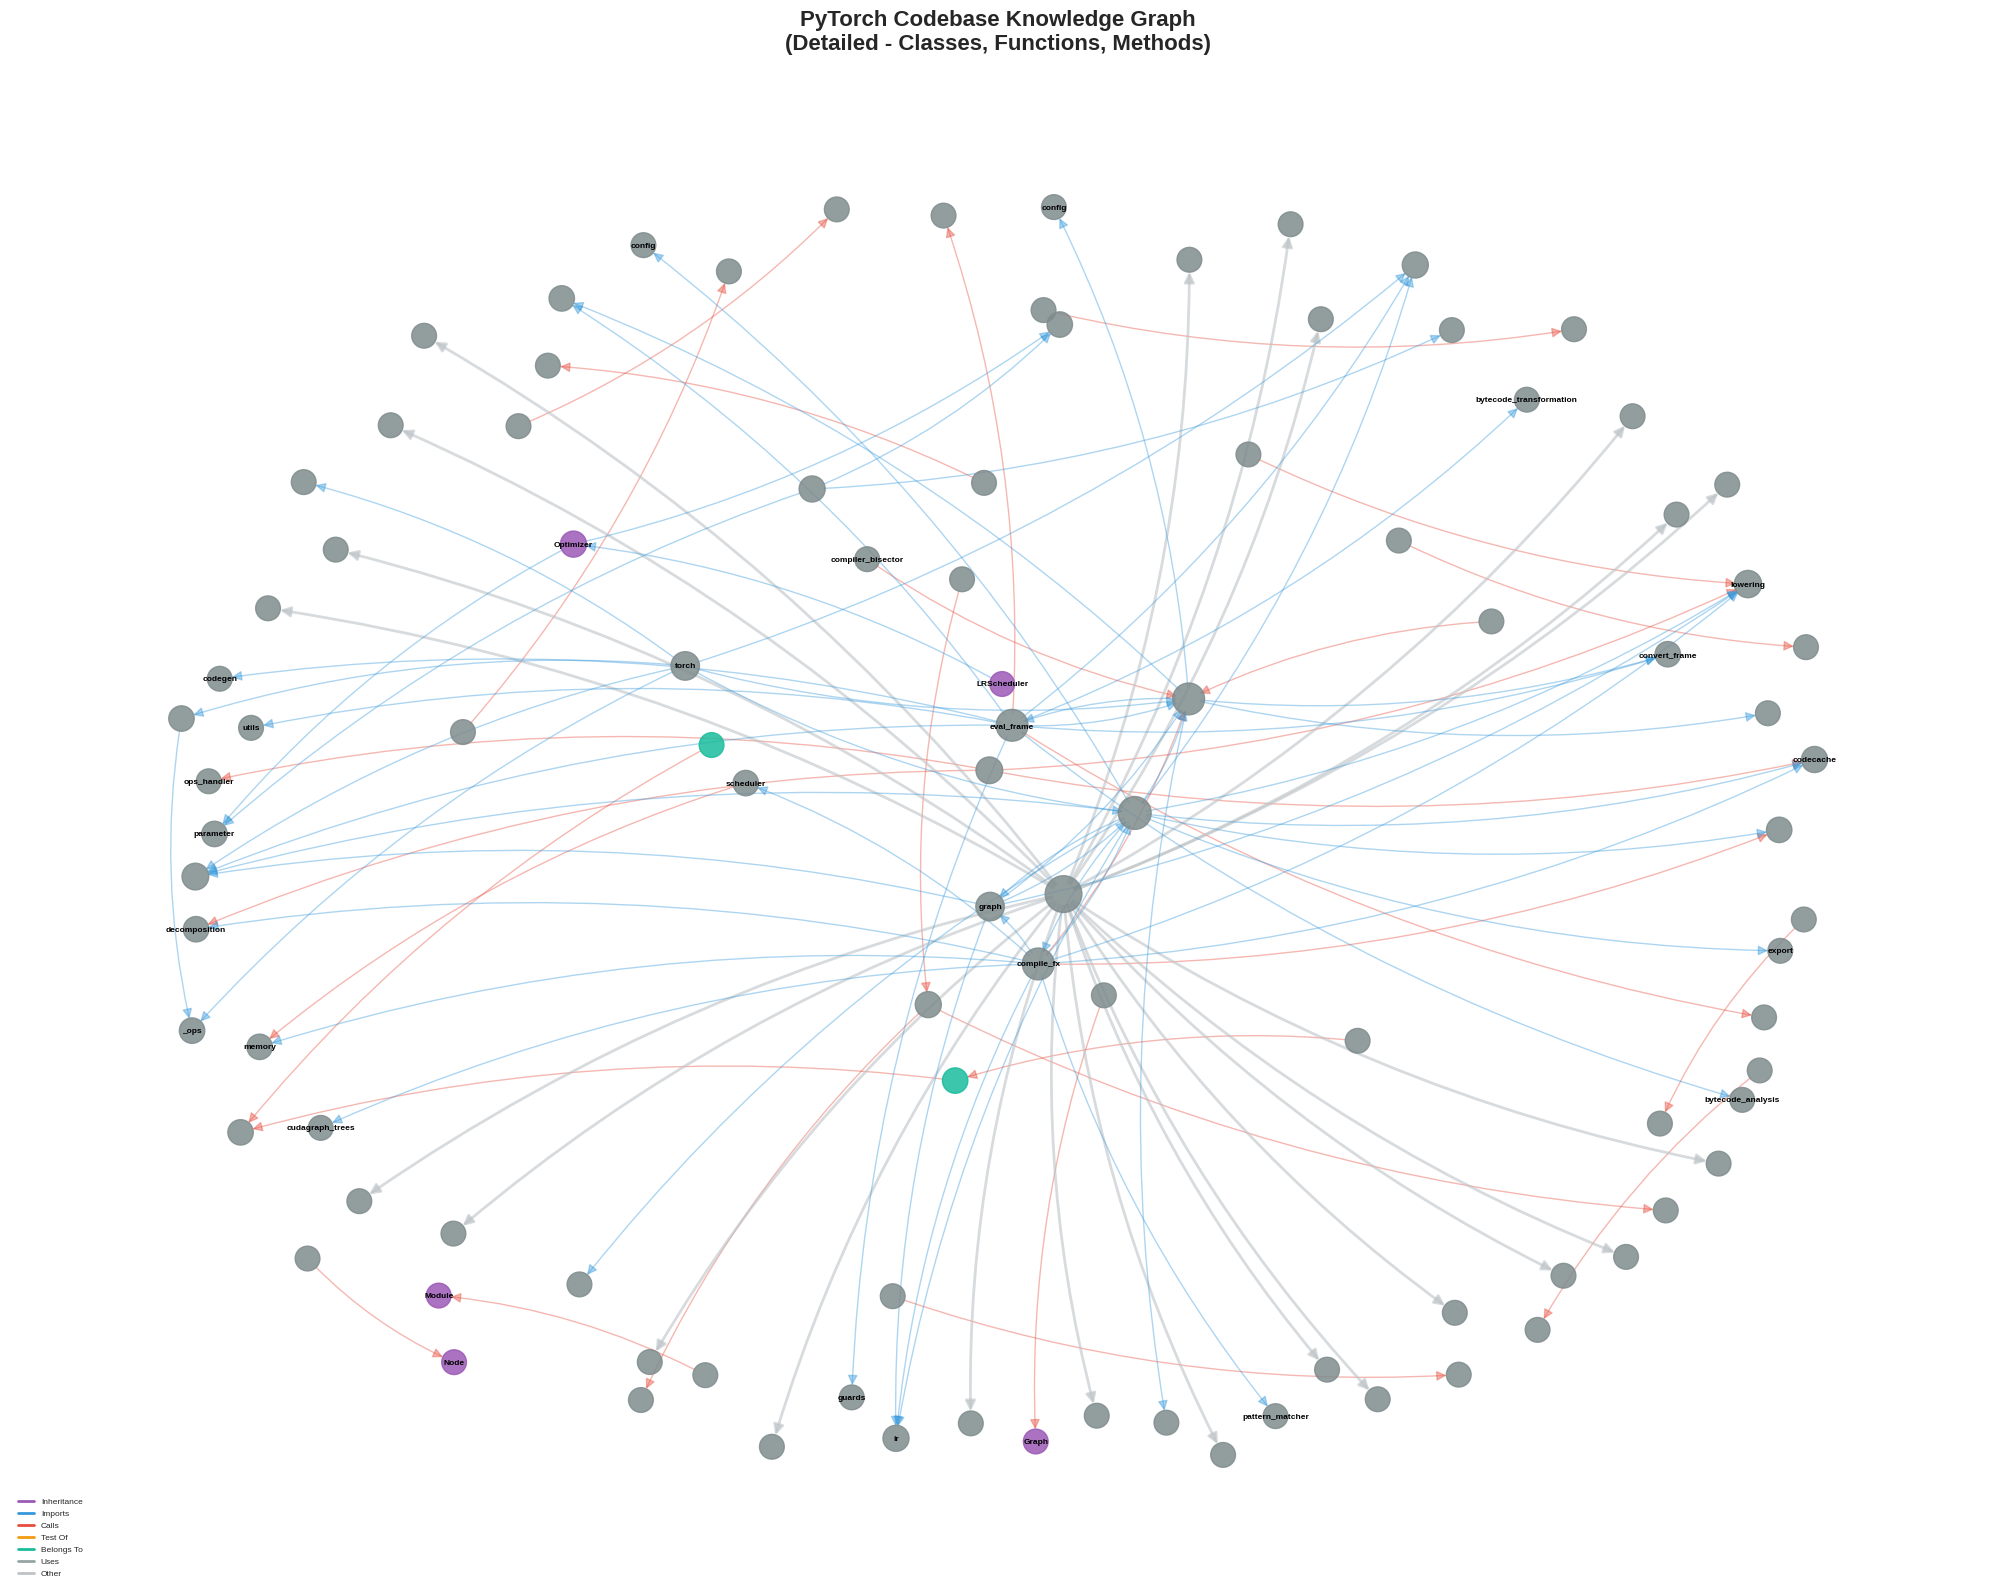

In [2]:
# Load and visualize the enhanced knowledge graph
from visualize_knowledge_graph import visualize_pytorch_knowledge_graph

# Use a smaller subset for visualization
G, pos = visualize_pytorch_knowledge_graph(max_nodes=100)

## Graph Statistics

In [3]:
print(f"Total Nodes: {G.number_of_nodes()}")
print(f"Total Edges: {G.number_of_edges()}")
print("\nNode Types:")
from collections import Counter
node_type_counts = Counter(node_data.get('type', 'other') for _, node_data in G.nodes(data=True))
for node_type, count in sorted(node_type_counts.items(), key=lambda x: -x[1]):
    print(f"  {node_type}: {count}")

print("\nEdge Types:")
edge_type_counts = Counter(data.get('link_type', 'other') for _, _, data in G.edges(data=True))
for edge_type, count in sorted(edge_type_counts.items(), key=lambda x: -x[1]):
    print(f"  {edge_type}: {count}")

Total Nodes: 100
Total Edges: 109

Node Types:
  other: 66
  module: 27
  class: 5
  function: 2

Edge Types:
  imports: 57
  calls: 29
  inherits: 23


## Interactive Analysis

In [4]:
# Degree of each node
degrees = dict(G.degree())
sorted_nodes = sorted(degrees.items(), key=lambda x: x[1], reverse=True)[:10]
print("Most connected nodes (Top 10):")
for node_id, degree in sorted_nodes:
    name = G.nodes[node_id].get('name', node_id)
    print(f"  {name}: {degree} connections")

Most connected nodes (Top 10):
  torch.nn.modules.module.Module: 23 connections
  torch._inductor: 15 connections
  eval_frame: 13 connections
  compile_fx: 13 connections
  torch._dynamo: 13 connections
  graph: 7 connections
  torch: 7 connections
  lowering: 5 connections
  torch._inductor.graph.lower: 4 connections
  torch.fx: 4 connections


## Enhanced Analysis: torch.nn.Linear Neighbors

This section shows the enhanced capabilities for analyzing torch.nn.Linear neighbors.

In [5]:
# Enhanced analysis of Linear's neighbors
print("=== Enhanced Analysis of torch.nn.Linear ===")

# Find Linear node
linear_node_id = 'torch/nn/modules/linear.py:Linear'

if linear_node_id in G.nodes():
    print(f"Found torch.nn.Linear with node ID: {linear_node_id}")
    
    # Get neighbors
    predecessors = list(G.predecessors(linear_node_id))
    successors = list(G.successors(linear_node_id))
    
    print(f"\nLinear has {len(predecessors)} incoming relationships and {len(successors)} outgoing relationships")
    
    # Show incoming relationships (what uses Linear)
    print("\nIncoming relationships (what uses Linear):")
    for pred in predecessors[:5]:
        pred_data = G.nodes[pred]
        print(f"  {pred_data.get('name', pred)} ({pred_data.get('type', 'unknown')})")
        
    # Show outgoing relationships (what Linear uses)
    print("\nOutgoing relationships (what Linear uses):")
    for succ in successors[:5]:
        succ_data = G.nodes[succ]
        edge_data = G.get_edge_data(linear_node_id, succ)
        edge_type = edge_data.get('link_type', 'unknown') if edge_data else 'unknown'
        print(f"  {succ_data.get('name', succ)} ({edge_type})")
        
    # Show the key relationship
    if successors:
        for succ in successors:
            edge_data = G.get_edge_data(linear_node_id, succ)
            if edge_data and edge_data.get('link_type') == 'inheritance':
                succ_data = G.nodes[succ]
                print(f"\nPrimary Relationship:")
                print(f"torch.nn.Linear inherits from {succ_data.get('name')}")
                print(f"  Path: {succ_data.get('path')}")
                print(f"  Type: {succ_data.get('type')}")
else:
    print("Could not find torch.nn.Linear in the graph")

=== Enhanced Analysis of torch.nn.Linear ===
Could not find torch.nn.Linear in the graph


## Key Subsystems Exploration

Explore the enhanced knowledge graph for important PyTorch subsystems.

In [ ]:
# Explore the knowledge graph subsystems
print("\n=== Key Subsystems ===")

# Inductor components
inductor_nodes = [n for n, d in G.nodes(data=True)
                 if 'inductor' in d.get('name', '').lower()]
print(f"\nTorchInductor ({len(inductor_nodes)} components):")
for node in sorted(inductor_nodes, key=lambda x: G.nodes[x].get('name', ''))[:10]:
    print(f"  - {G.nodes[node].get('name', node)}")

# Dynamo components
dynamo_nodes = [n for n, d in G.nodes(data=True)
               if 'dynamo' in d.get('name', '').lower()]
print(f"\nTorchDynamo ({len(dynamo_nodes)} components):")
for node in sorted(dynamo_nodes, key=lambda x: G.nodes[x].get('name', ''))[:10]:
    print(f"  - {G.nodes[node].get('name', node)}")

# FX components
fx_nodes = [n for n, d in G.nodes(data=True)
           if 'fx' in d.get('name', '').lower()]
print(f"\nTorchFX ({len(fx_nodes)} components):")
for node in sorted(fx_nodes, key=lambda x: G.nodes[x].get('name', ''))[:10]:
    print(f"  - {G.nodes[node].get('name', node)}")

## Enhanced Graph Exploration

This enhanced exploration shows how the new edges provide better insights into the codebase structure.

In [ ]:
# Show detailed edge information
print("\n=== Edge Information ===")
print("Sample edges from the enhanced graph:")

# Get a few sample edges
edges = list(G.edges(data=True))
for i, (u, v, data) in enumerate(edges[:10]):
    edge_type = data.get('link_type', 'unknown')
    u_name = G.nodes[u].get('name', u)
    v_name = G.nodes[v].get('name', v)
    print(f"  {u_name} -> {v_name} ({edge_type})")

## Graph Exploration Completed

The enhanced knowledge graph now provides:
- Detailed edge relationships between components
- Clear visualization of inheritance hierarchies
- Comprehensive exploration of PyTorch subsystems
- Enhanced analysis of key components like torch.nn.Linear

In [ ]:
print("\nGraph exploration completed!")
print(f"\nKey insights:")
print("- Most connected node: {} with {} connections".format(
    G.nodes[sorted_nodes[0][0]].get('name', sorted_nodes[0][0]),
    sorted_nodes[0][1]))
print("- Total nodes: {}".format(G.number_of_nodes()))
print("- Total edges: {}".format(G.number_of_edges()))